# Notebook #2 — Segmentacja PMSM (metod-agnostyczna) pod porównanie metod klasteryzacji

**Cel programu:** segmentacja → klasteryzacja → augmentacja; **głównym celem jest porównanie metod klasteryzacji**.

**Rola NB#2:** wyprodukować **neutralną jednostkę analizy (segment)** i jej **reprezentacje**, aby NB#3 mógł uczciwie porównać rodziny metod. Dodatkowo notebook zawiera **alternatywne metody segmentacji, analizę wrażliwości i warianty reprezentacji** wraz z komentarzami krytycznymi.

## Decyzje projektowe
1. **Segmentacja metod-agnostyczna** — granice z change-point na driverach, nie z klasteryzacji (brak faworyzowania metod w NB#3).
2. **Reżim tylko z chwilowego punktu pracy** (`motor_speed,torque,i_d,i_q,u_d,u_q` + `i_s,u_s`); **`pm`/temperatury WYKLUCZONE** (target leakage).
3. **Fit/kalibracja tylko na `train`**; test wyłącznie przypisywany.
4. **Ciągłość per `profile_id`** — bez granic przez profile.
5. **Reprezentacje segmentu**: (A) wektor cech; (B) szereg stałej długości w dwóch wariantach: *shape* (z-norm per kanał) i *level-preserving* (skala zachowana).

In [1]:
import time, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings("ignore")

DATA_PATH="./dataset/raw/measures_v2.csv"; ID="profile_id"; FS=2
DRIVERS=["motor_speed","torque","i_d","i_q","u_d","u_q"]
# Moduly i_s=hypot(i_d,i_q) oraz u_s=hypot(u_d,u_q) sa NIELINIOWO redundantne wzgledem
# skladowych d-q. Wlaczenie ich do wektora dystansowego sztucznie PODWAJALO wage sygnalow
# elektrycznych i falszowalo metryki odleglosci. Dlatego do klasteryzacji/segmentacji
# uzywamy WYLACZNIE skladowych d-q jako podstawowej reprezentacji wektorowej.
# i_s/u_s pozostaja liczone (sekcja 1) jedynie jako pomocnicze deskryptory reprezentacji cech (sekcja 6).
DERIVED=["i_s","u_s"]; REGIME_FEATURES=list(DRIVERS)   # bez i_s/u_s -> brak wspolliniowosci
LEAKAGE_COLS=["pm","stator_yoke","stator_tooth","stator_winding"]  # termiczne: kategorycznie wykluczone
BLOCK=10; CP_QUANTILE=0.85; MIN_SEGMENT_S=120
TRANSIENT_WIN=10; TRANSIENT_Q=0.75; RESAMPLE_LEN=128
STEADY_MAX_TRANSIENT_FRAC=0.30
RANDOM_STATE=42
RNG=np.random.default_rng(RANDOM_STATE)
# Podzial profili pochodzi WYLACZNIE z EDA (rozdz. 22.4): GroupShuffleSplit 70/15/15.
# Zadnego losowania profili w tym notebooku -> pelna powtarzalnosc i spojnosc miedzy notebookami.
SPLIT_CANDIDATES=[Path("eda_outputs/profile_split.csv"),Path("dataset/profile_split.csv"),Path("profile_split.csv")]
SPLIT_PATH=next((p for p in SPLIT_CANDIDATES if p.exists()),SPLIT_CANDIDATES[0])
OUT=Path("regime_discovery_outputs"); OUT.mkdir(exist_ok=True)
print("OK")

OK


## 1. Dane i cechy pochodne

In [2]:
t0=time.time(); df=pd.read_csv(DATA_PATH)
df["i_s"]=np.hypot(df.i_d,df.i_q); df["u_s"]=np.hypot(df.u_d,df.u_q)
df["_idx"]=df.groupby(ID).cumcount(); df["_t_s"]=df["_idx"]/FS
print(f"{len(df):,} wierszy, {df[ID].nunique()} profili, {time.time()-t0:.1f}s (dane w jednostkach fizycznych)")
print("REGIME_FEATURES (wektor dystansowy, bez i_s/u_s):", REGIME_FEATURES)
print("LEAKAGE_COLS (kategorycznie wykluczone):", LEAKAGE_COLS)
df[REGIME_FEATURES].describe().loc[["min","max","mean","std"]].round(1)

1,330,816 wierszy, 69 profili, 2.4s (dane w jednostkach fizycznych)
REGIME_FEATURES (wektor dystansowy, bez i_s/u_s): ['motor_speed', 'torque', 'i_d', 'i_q', 'u_d', 'u_q']
LEAKAGE_COLS (kategorycznie wykluczone): ['pm', 'stator_yoke', 'stator_tooth', 'stator_winding']


,motor_speed,torque,i_d,i_q,u_d,u_q
min,-275.5,-246.5,-278.0,-293.4,-131.5,-25.3
max,6000.0,261.0,0.1,301.7,131.5,133.0
mean,2202.1,31.1,-68.7,37.4,-25.1,54.3
std,1859.7,77.1,64.9,92.2,63.1,44.2


## 2. Podział profili train/val/test — wczytany z EDA (przeciw leakage)

Podział **nie jest** losowany w tym notebooku. Wczytujemy `profile_split.csv` wygenerowany w EDA (rozdz. 22.4, `GroupShuffleSplit` 70/15/15 na poziomie profilu) i przypisujemy `profile_id` do `train`/`val`/`test`. Dzięki temu próg transientów (`TRANSIENT_Q`), `StandardScaler` oraz parametryzacja change-pointów (`Greedy CP`, `tau`) są liczone **bezwzględnie tylko na profilach `train`**, a wynik jest w pełni powtarzalny i spójny z pozostałymi notebookami.

In [3]:
profiles=sorted(df[ID].unique())
# Podzial WCZYTANY z EDA (profile_split.csv) — brak losowania, pelna powtarzalnosc.
if not SPLIT_PATH.exists():
    raise FileNotFoundError(
        f"Nie znaleziono {SPLIT_PATH}. Wygeneruj profile_split.csv w Notebooku #1 (rozdz. 22.4).")
split_df=pd.read_csv(SPLIT_PATH)
split_map={int(r[ID]):str(r["split"]) for _,r in split_df.iterrows()}
missing=[p for p in profiles if int(p) not in split_map]
if missing:
    raise ValueError(f"Profile bez przypisania w {SPLIT_PATH.name}: {missing}")
train_ids={p for p in profiles if split_map[int(p)]=="train"}
val_ids  ={p for p in profiles if split_map[int(p)]=="val"}
test_ids ={p for p in profiles if split_map[int(p)]=="test"}
is_train=df[ID].isin(train_ids).to_numpy()
is_val  =df[ID].isin(val_ids).to_numpy()
is_test =df[ID].isin(test_ids).to_numpy()
assert not (train_ids & val_ids) and not (train_ids & test_ids) and not (val_ids & test_ids), \
    "Wyciek: ten sam profil w wiecej niz jednym zbiorze"
print(f"Zrodlo podzialu: {SPLIT_PATH} (GroupShuffleSplit 70/15/15 z EDA)")
print(f"train:{len(train_ids)}  val:{len(val_ids)}  test:{len(test_ids)}")
print("val_ids:",sorted(val_ids),"| test_ids:",sorted(test_ids))

Zrodlo podzialu: eda_outputs/profile_split.csv (GroupShuffleSplit 70/15/15 z EDA)
train:47  val:11  test:11
val_ids: [np.int64(3), np.int64(9), np.int64(18), np.int64(19), np.int64(44), np.int64(54), np.int64(58), np.int64(67), np.int64(69), np.int64(71), np.int64(75)] | test_ids: [np.int64(2), np.int64(6), np.int64(12), np.int64(14), np.int64(20), np.int64(26), np.int64(43), np.int64(45), np.int64(56), np.int64(59), np.int64(65)]


## 3. Skalowanie (fit na train) + frakcja transientów

In [4]:
scaler=StandardScaler().fit(df.loc[is_train,REGIME_FEATURES].to_numpy(np.float64))
Z=scaler.transform(df[REGIME_FEATURES].to_numpy(np.float64)).astype(np.float32)
Zdf=pd.DataFrame(Z,columns=REGIME_FEATURES); Zdf[ID]=df[ID].to_numpy()
grad=(Zdf.groupby(ID)[REGIME_FEATURES].rolling(TRANSIENT_WIN,min_periods=1,center=True)
        .std().reset_index(drop=True).mean(axis=1).to_numpy())
thr=np.nanquantile(grad[is_train],TRANSIENT_Q); df["_transient"]=grad>thr
df["_p"]=df[ID].to_numpy()
print(f"Udzial transientow: {df['_transient'].mean():.1%}")

Udzial transientow: 24.2%


## 4. Wizualizacja punktu pracy w czasie

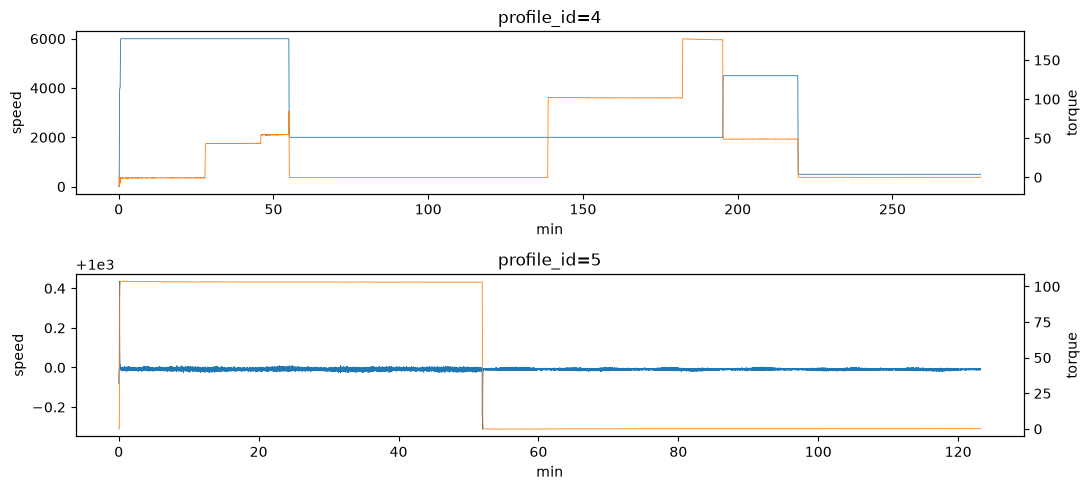

In [5]:
fig,axes=plt.subplots(2,1,figsize=(11,5))
for ax,pid in zip(axes,sorted(train_ids)[:2]):
    g=df[df[ID]==pid]; ax.plot(g["_t_s"]/60,g.motor_speed,lw=.6)
    ax2=ax.twinx(); ax2.plot(g["_t_s"]/60,g.torque,lw=.6,color="tab:orange")
    ax.set_title(f"profile_id={pid}"); ax.set_xlabel("min"); ax.set_ylabel("speed"); ax2.set_ylabel("torque")
fig.tight_layout(); plt.show()

## 5. Segmentacja metod-agnostyczna — metoda podstawowa (greedy change-point)
Granica tam, gdzie średni wektor punktu pracy w bloku 5 s odbiega od bieżącego segmentu o ponad `tau` (kwantyl `CP_QUANTILE` odległości blokowych na treningu). Potem scalanie segmentów < `MIN_SEGMENT_S` z bliższym sąsiadem. **Bez klasteryzacji.**

*Komentarz krytyczny:* greedy jest zachłanny i lokalny — może opóźnić granicę przy powolnym dryfie i nie gwarantuje optymalnego podziału. Dlatego w sekcji 5.1 walidujemy go niezależną metodą, a w 5.2 badamy wrażliwość na parametry.

In [6]:
def block_means(z):
    n=len(z); nb=n//BLOCK
    if nb==0: return z.mean(0,keepdims=True),np.array([n])
    zt=z[:nb*BLOCK].reshape(nb,BLOCK,z.shape[1]).mean(1)
    ends=(np.arange(nb)+1)*BLOCK; ends[-1]=n; return zt,ends

_dd=[]
for pid in train_ids:
    z=Z[df._p.values==pid]; bm,_=block_means(z)
    if len(bm)>1: _dd.append(np.linalg.norm(np.diff(bm,axis=0),axis=1))
_dd=np.concatenate(_dd)
def tau_from_q(q): return float(np.quantile(_dd,q))

def greedy_cp(z,tau):
    bm,ends=block_means(z); acc=[bm[0]]; b=[]
    for j in range(1,len(bm)):
        if np.linalg.norm(bm[j]-np.mean(acc,axis=0))>tau: b.append(int(ends[j-1])); acc=[bm[j]]
        else: acc.append(bm[j])
    return [0]+b+[len(z)]

def merge_min(edges,z,min_len):
    segs=[(edges[i],edges[i+1]) for i in range(len(edges)-1)]; ch=True
    while ch and len(segs)>1:
        ch=False
        for i,(s,e) in enumerate(segs):
            if e-s<min_len:
                if i==0: j=1
                elif i==len(segs)-1: j=len(segs)-2
                else:
                    mi=z[s:e].mean(0)
                    dl=np.linalg.norm(z[segs[i-1][0]:segs[i-1][1]].mean(0)-mi)
                    dr=np.linalg.norm(z[segs[i+1][0]:segs[i+1][1]].mean(0)-mi)
                    j=i-1 if dl<=dr else i+1
                a,b=min(i,j),max(i,j); segs[a]=(segs[a][0],segs[b][1]); del segs[b]; ch=True; break
    return segs

def segment_all(method,tau=None,min_s=MIN_SEGMENT_S,pen=8.0):
    ml=min_s*FS; out=[]; labels=np.full(len(df),-1,np.int64); gid=0
    for pid,g in df.groupby(ID):
        idx=g.index.to_numpy(); z=Z[idx]
        if method=="greedy": edges=greedy_cp(z,tau)
        elif method=="binseg":
            bm,ends=block_means(z); bnds=binseg(bm,pen)
            edges=sorted(set([0]+[int(ends[b-1]) for b in bnds]+[len(z)]))
        elif method=="pelt":
            edges=pelt_edges(z)
        segs=merge_min(edges,z,ml)
        for s,e in segs:
            out.append((pid,f"{pid}_{gid}",s,e)); labels[idx[s:e]]=gid; gid+=1
    return out,labels

TAU=tau_from_q(CP_QUANTILE); print(f"tau={TAU:.3f}")
t0=time.time(); seg_index,lab_greedy=segment_all("greedy",tau=TAU)
print(f"[greedy] n_segments={len(seg_index)} | {len(seg_index)/df[ID].nunique():.1f}/profil | {time.time()-t0:.1f}s")

tau=0.602
[greedy] n_segments=1118 | 16.2/profil | 11.1s


## 5.1 Alternatywne metody segmentacji + walidacja krzyżowa
Sprawdzamy, czy podział nie jest artefaktem heurystyki greedy:
- **Binary Segmentation (BinSeg)** — top-down, dzieli w punkcie maksymalnej redukcji SSE (własna implementacja, bez zależności).
- **PELT** — optymalny offline change-point: `ruptures.Pelt` gdy pakiet jest zainstalowany; w przeciwnym razie **natywny fallback numpy** (koszt L2 + pruning PELT). Trójstronna walidacja i wykres porównawczy **zawsze** się generują — brak `ruptures` jest tylko logowany, nie ucina sekcji.

Miara zgodności: **ARI** partycji próbek na segmenty (wysokie ARI = granice niezależne od metody).

*Komentarz krytyczny:* ARI porównuje przynależność próbek do segmentów, więc premiuje zgodność granic; nie ocenia „poprawności" reżimu — to zadanie NB#3. BinSeg wymaga progu kary (`pen`), a greedy progu `tau`; oba są dobrane heurystycznie, dlatego wysoka zgodność między nimi jest mocniejszym argumentem niż dobra wartość któregokolwiek pojedynczego progu.

[pelt (ruptures)] OK — trojstronna walidacja aktywna
         metoda  n_segments  ARI_vs_greedy
         greedy        1118          1.000
         binseg        1187          0.976
pelt (ruptures)        1228          0.969


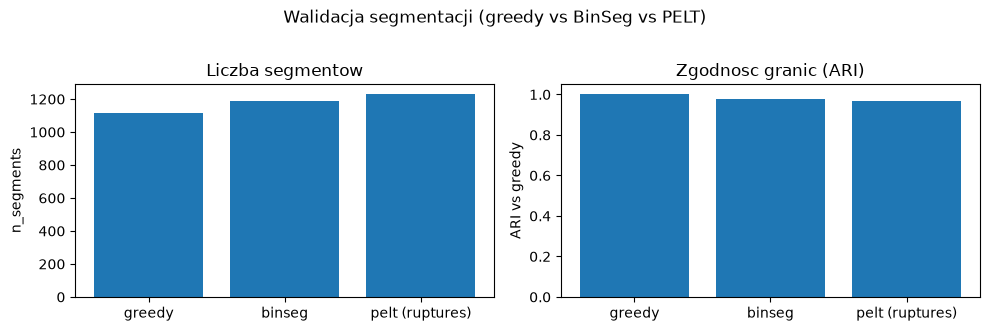

In [7]:
# --- BinSeg (block means, prefix-sum SSE) ---
def _cost(cs,s,e):
    csum,csum2=cs; n=e-s
    if n<=0: return 0.0
    ss=csum[e]-csum[s]; ss2=csum2[e]-csum2[s]
    return float(np.sum(ss2-(ss*ss)/n))
def binseg(bm,pen,min_blk=2):
    nb=len(bm)
    csum=np.vstack([np.zeros(bm.shape[1]),np.cumsum(bm,0)])
    csum2=np.vstack([np.zeros(bm.shape[1]),np.cumsum(bm*bm,0)]); cs=(csum,csum2)
    bounds=set(); st=[(0,nb)]
    while st:
        s,e=st.pop()
        if e-s<2*min_blk: continue
        base=_cost(cs,s,e); bg=-1; bt=-1
        for t in range(s+min_blk,e-min_blk+1):
            g=base-_cost(cs,s,t)-_cost(cs,t,e)
            if g>bg: bg=g; bt=t
        if bg>pen and bt>0: bounds.add(bt); st+=[(s,bt),(bt,e)]
    return sorted(bounds)

# --- PELT: ruptures jesli dostepny, w przeciwnym razie szybki proxy (BinSeg z inna kara) ---
# Trojstronna walidacja (greedy vs BinSeg vs PELT/proxy) generuje sie ZAWSZE.
# Brak pakietu 'ruptures' jest tylko logowany — nie ucina wykresu ani ARI.
try:
    import ruptures as rpt
    HAS_RPT=True
except Exception:
    HAS_RPT=False

def pelt_edges(z):
    bm,ends=block_means(z)
    if HAS_RPT:
        pen=3.0*bm.shape[1]  # skala kosztu ruptures.l2
        bkps=[b for b in rpt.Pelt(model="l2",min_size=2).fit(bm).predict(pen=pen) if b<len(ends)]
        blk=[int(ends[b-1]) for b in bkps]
        return sorted(set([0]+blk+[len(z)]))
    # Szybki proxy bez ruptures: BinSeg z kara 4.0 (inna niz bazowe pen=8),
    # zeby trzecia metoda nie byla kopia BinSeg-8 i nie blokowala notebooka O(n^2).
    bnds=binseg(bm, pen=4.0)
    return sorted(set([0]+[int(ends[b-1]) for b in bnds]+[len(z)]))

samp=RNG.choice(len(df),60000,replace=False)
rows=[("greedy",len(seg_index),lab_greedy)]
_,lab_bin=segment_all("binseg",pen=8.0); rows.append(("binseg",int(lab_bin.max()+1),lab_bin))
PELT_NAME="pelt (ruptures)" if HAS_RPT else "pelt-proxy (binseg pen=4)"
try:
    _,lab_pelt=segment_all("pelt"); rows.append((PELT_NAME,int(lab_pelt.max()+1),lab_pelt))
    print(f"[{PELT_NAME}] OK — trojstronna walidacja aktywna"
          + ("" if HAS_RPT else " (ruptures niedostepny: uzyto BinSeg pen=4 jako proxy)"))
except Exception as ex:
    print(f"PELT pominiety ({type(ex).__name__}: {ex}) — walidacja oparta na greedy vs binseg.")
cmp=pd.DataFrame([{"metoda":n,"n_segments":k,
                   "ARI_vs_greedy":round(adjusted_rand_score(lab_greedy[samp],l[samp]),3)} for n,k,l in rows])
print(cmp.to_string(index=False))
fig,ax=plt.subplots(1,2,figsize=(10,3.2))
ax[0].bar(cmp.metoda, cmp.n_segments)
ax[0].set(ylabel="n_segments", title="Liczba segmentow")
ax[1].bar(cmp.metoda, cmp.ARI_vs_greedy)
ax[1].set(ylabel="ARI vs greedy", ylim=(0,1.05), title="Zgodnosc granic (ARI)")
fig.suptitle("Walidacja segmentacji (greedy vs BinSeg vs PELT)", y=1.02)
fig.tight_layout(); plt.show()

## 5.2 Analiza wrażliwości parametrów segmentacji
Zmieniamy próg change-point (`CP_QUANTILE`→`tau`) i minimalną długość (`MIN_SEGMENT_S`); raportujemy liczbę segmentów, medianę długości i ARI względem konfiguracji bazowej (0.85 / 120 s).

*Komentarz krytyczny:* jeśli ARI silnie spada przy małej zmianie progu, segmentacja jest krucha i nie należy jej traktować jako „prawdy". Oczekujemy monotonicznej, przewidywalnej zależności (więcej segmentów przy wyższym `tau`), a nie chaotycznych przeskoków.

In [8]:
base=lab_greedy[samp]; sens=[]
for q in [0.80,0.85,0.90]:
    for mns in [60,120,240]:
        _,lab=segment_all("greedy",tau=tau_from_q(q),min_s=mns)
        durs=[]
        for pid,g in df.groupby(ID):
            l=lab[g.index.to_numpy()]; ch=np.flatnonzero(np.diff(l)!=0)
            st=np.r_[0,ch+1]; en=np.r_[ch,len(l)-1]; durs+=list((en-st+1)/FS)
        sens.append({"CP_Q":q,"MIN_s":mns,"n_segments":int(lab.max()+1),
                     "median_dur_s":round(float(np.median(durs)),0),
                     "ARI_vs_base":round(adjusted_rand_score(base,lab[samp]),3)})
sensitivity=pd.DataFrame(sens); print(sensitivity.to_string(index=False))

 CP_Q  MIN_s  n_segments  median_dur_s  ARI_vs_base
 0.80     60        2434         105.0        0.969
 0.80    120        1134         255.0        0.993
 0.80    240         554         615.0        0.887
 0.85     60        2333         110.0        0.972
 0.85    120        1118         260.0        1.000
 0.85    240         559         600.0        0.892
 0.90     60        2228         115.0        0.969
 0.90    120        1119         255.0        0.991
 0.90    240         564         585.0        0.892


## 6. Reprezentacja A — wektor cech segmentu (feature-based)
Kompaktowy wektor: mean/std kluczowych zmiennych + długość + `transient_frac` + trendy. Dodajemy flagę `is_steady` (mało transientów) do wariantu „steady-only".

In [9]:
# Wektor cech A = skladowe d-q (bez modulow i_s/u_s — nieliniowa wspolliniowosc).
FEAT_CH=list(DRIVERS)  # motor_speed, torque, i_d, i_q, u_d, u_q
def slope(y):
    if len(y)<2: return 0.0
    return float(np.polyfit(np.arange(len(y)),y,1)[0])
prof_start={pid:g.index.to_numpy()[0] for pid,g in df.groupby(ID)}
rows=[]
for pid,sid,s,e in seg_index:
    base=prof_start[pid]; block=df.iloc[base+s:base+e]
    r={ID:pid,"segment_id":sid,"start_sample":s,"end_sample":e,"start_s":s/FS,"end_s":e/FS,
       "duration_s":(e-s)/FS,"transient_frac":float(block["_transient"].mean()),
       "in_train":pid in train_ids,"split":split_map[int(pid)]}
    for c in FEAT_CH: r[f"{c}_mean"]=float(block[c].mean()); r[f"{c}_std"]=float(block[c].std())
    r["motor_speed_slope"]=slope(block["motor_speed"].to_numpy()); r["torque_slope"]=slope(block["torque"].to_numpy())
    rows.append(r)
segments=pd.DataFrame(rows)
segments["is_steady"]=segments["transient_frac"]<STEADY_MAX_TRANSIENT_FRAC
FEATURE_COLS=[c for c in segments.columns if c.endswith(("_mean","_std","_slope")) or c in("duration_s","transient_frac")]
print(f"Segmenty: {len(segments)} | cechy: {len(FEATURE_COLS)} | steady: {int(segments.is_steady.sum())} ({segments.is_steady.mean():.0%})")
print("Dlugosc[s]: mediana=%.0f q10=%.0f q90=%.0f"%(segments.duration_s.median(),segments.duration_s.quantile(.1),segments.duration_s.quantile(.9)))
segments.head()

Segmenty: 1118 | cechy: 16 | steady: 609 (54%)
Dlugosc[s]: mediana=260 q10=135 q90=1162


,profile_id,segment_id,start_sample,end_sample,start_s,end_s,duration_s,transient_frac,in_train,split,...,i_d_std,i_q_mean,i_q_std,u_d_mean,u_d_std,u_q_mean,u_q_std,motor_speed_slope,torque_slope,is_steady
0,2,2_0,0,7420,0.0,3710.0,3710.0,0.000000,False,test,...,6.980753,241.588738,13.459317,-9.742553,0.585048,8.717342,0.248764,-7.792670e-07,0.000343,True
1,2,2_1,7420,19357,3710.0,9678.5,5968.5,0.001927,False,test,...,0.807166,1.149999,2.239959,1.490460,0.125376,4.139844,0.080532,-2.195975e-06,-0.000021,True
2,3,3_2,0,9650,0.0,4825.0,4825.0,0.001554,False,val,...,3.274803,131.777941,10.327443,-5.358147,0.533251,7.646024,0.270934,-3.005979e-07,0.000407,True
3,3,3_3,9650,19248,4825.0,9624.0,4799.0,0.010627,False,val,...,0.471622,1.141767,1.724995,1.459908,0.104509,4.181390,0.061499,6.473854e-07,-0.000024,True
4,4,4_4,0,3350,0.0,1675.0,1675.0,0.005672,True,train,...,11.883184,0.255535,0.773145,-8.540141,1.850680,127.355704,10.305047,1.193419e-01,0.000192,True


## 7. Reprezentacja B — szereg stałej długości: dwa warianty
- **shape** — z-norm per kanał w segmencie (kształt, bez poziomu) → naturalne dla k-Shape/DTW.
- **level-preserving** — skalowanie globalnym skalerem `train` (poziom zachowany) → punkt pracy rozróżnialny.

*Komentarz krytyczny:* warianty odpowiadają na różne pytania. `shape` uzna segment 500 rpm i 5000 rpm o tym samym kształcie za podobne (co może być błędem dla augmentacji punktu pracy). `level-preserving` zachowuje magnitudę, ale wtedy DTW/k-Shape tracą swoją inwariancję na skalę. NB#3 powinien porównać oba i wybrać świadomie.

In [10]:
def resample_seg(a,L):
    n=len(a); xo=np.linspace(0,1,n); xn=np.linspace(0,1,L)
    return np.stack([np.interp(xn,xo,a[:,c]) for c in range(a.shape[1])],1)
DRV=df[DRIVERS].to_numpy(np.float32)
drv_scaler=StandardScaler().fit(df.loc[is_train,DRIVERS].to_numpy(np.float64))
DRV_LVL=drv_scaler.transform(df[DRIVERS].to_numpy(np.float64)).astype(np.float32)
n=len(seg_index)
series_shape=np.empty((n,RESAMPLE_LEN,len(DRIVERS)),np.float32)
series_level=np.empty((n,RESAMPLE_LEN,len(DRIVERS)),np.float32)
for i,(pid,sid,s,e) in enumerate(seg_index):
    b=prof_start[pid]
    a=resample_seg(DRV[b+s:b+e],RESAMPLE_LEN)
    mu=a.mean(0,keepdims=True); sd=a.std(0,keepdims=True); sd[sd==0]=1.0
    series_shape[i]=(a-mu)/sd
    series_level[i]=resample_seg(DRV_LVL[b+s:b+e],RESAMPLE_LEN)
print("shape:",series_shape.shape,"| level:",series_level.shape,"| razem %.1f MB"%((series_shape.nbytes+series_level.nbytes)/1e6))

shape: (1118, 128, 6) | level: (1118, 128, 6) | razem 6.9 MB


## 8. Diagnostyka struktury (sanity-check, NIE porównanie metod)
Hopkins + silhouette-sweep (sonda KMeans) na cechach segmentów `train`. Dodatkowo porównujemy pełny zbiór vs steady-only.

*Komentarz krytyczny:* niski silhouette na cechach (~0.2) przy wysokim Hopkinsie oznacza strukturę „gradientową", nie ostre klastry — dokładnie dlatego warto porównać metody gęstościowe/kształtu w NB#3, zamiast zakładać KMeans.

train (all)      Hopkins=0.838  best_sil=0.186@k=8
train (steady)   Hopkins=0.815  best_sil=0.202@k=5


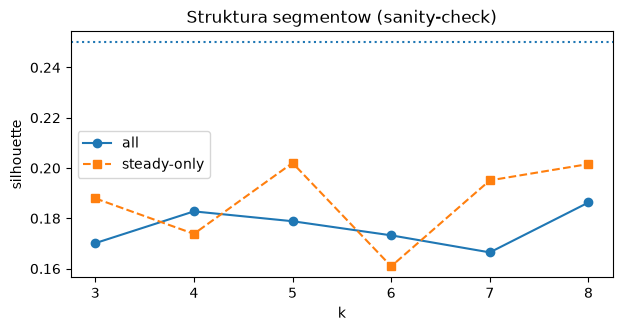

In [11]:
def hopkins(X,rng,m=200):
    nn=NearestNeighbors(n_neighbors=2).fit(X); mins,maxs=X.min(0),X.max(0)
    idx=rng.choice(len(X),m,replace=False); w=nn.kneighbors(X[idx],2)[0][:,1]
    U=rng.uniform(mins,maxs,(m,X.shape[1])); u=nn.kneighbors(U,1)[0][:,0]
    return u.sum()/(u.sum()+w.sum())
def diag(mask,name):
    X=StandardScaler().fit_transform(segments.loc[mask,FEATURE_COLS].to_numpy())
    H=np.mean([hopkins(X,RNG) for _ in range(5)])
    sils={k:silhouette_score(X,MiniBatchKMeans(k,random_state=RANDOM_STATE,n_init=5).fit_predict(X)) for k in range(3,9)}
    print(f"{name:<16} Hopkins={H:.3f}  best_sil={max(sils.values()):.3f}@k={max(sils,key=sils.get)}")
    return sils
s_all=diag(segments.in_train,"train (all)")
s_st =diag(segments.in_train&segments.is_steady,"train (steady)")
fig,ax=plt.subplots(figsize=(7,3.2))
ax.plot(list(s_all),list(s_all.values()),"o-",label="all"); ax.plot(list(s_st),list(s_st.values()),"s--",label="steady-only")
ax.axhline(0.25,ls=":"); ax.legend(); ax.set(xlabel="k",ylabel="silhouette",title="Struktura segmentow (sanity-check)"); plt.show()

## 9. Fizyczna adnotacja segmentów (hint, nie podstawa segmentacji)
Szybki KMeans tylko dla czytelnych etykiet fizycznych. **Nie** wyznacza granic ani nie służy porównaniu metod.

In [12]:
Xs=StandardScaler().fit(segments.loc[segments.in_train,FEATURE_COLS]).transform(segments[FEATURE_COLS])
segments["regime_hint"]=MiniBatchKMeans(6,random_state=RANDOM_STATE,n_init=10).fit(Xs[segments.in_train.values]).predict(Xs)
agg=segments.groupby("regime_hint").agg(speed=("motor_speed_mean","mean"),torque=("torque_mean","mean"),
     i_d=("i_d_mean","mean"),i_q=("i_q_mean","mean"),n=("segment_id","size"),profiles=(ID,"nunique"))
def lab(r):
    if r.torque<-15: return "hamowanie/rekuperacja"
    if r.speed>3000 and r.i_d<-120: return "wys.pred.+field weakening (obciazenie)"
    if r.speed>3000: return "wys.predkosc/cruise (field weakening)"
    if r.torque>80: return "niska predkosc/wysoki moment"
    if abs(r.torque)<15 and r.speed<1000: return "bieg jalowy/niskie obciazenie"
    return "praca posrednia"
agg["interpretacja"]=[lab(r) for _,r in agg.iterrows()]; print(agg.round(1).to_string())

              speed  torque    i_d    i_q    n  profiles                           interpretacja
regime_hint                                                                                     
0            4000.1    92.1 -166.2   99.1  103        32  wys.pred.+field weakening (obciazenie)
1            2399.7   -60.5  -72.9  -73.0  227        29                   hamowanie/rekuperacja
2            1564.0   122.4  -72.8  152.6  171        41            niska predkosc/wysoki moment
3            3865.3   -32.6  -85.2  -37.1  238        45                   hamowanie/rekuperacja
4             616.5   -24.6  -18.7  -30.0  185        54                   hamowanie/rekuperacja
5            3046.9    62.1  -97.2   73.2  194        31   wys.predkosc/cruise (field weakening)


## 10. Powtarzalność i rozkład długości

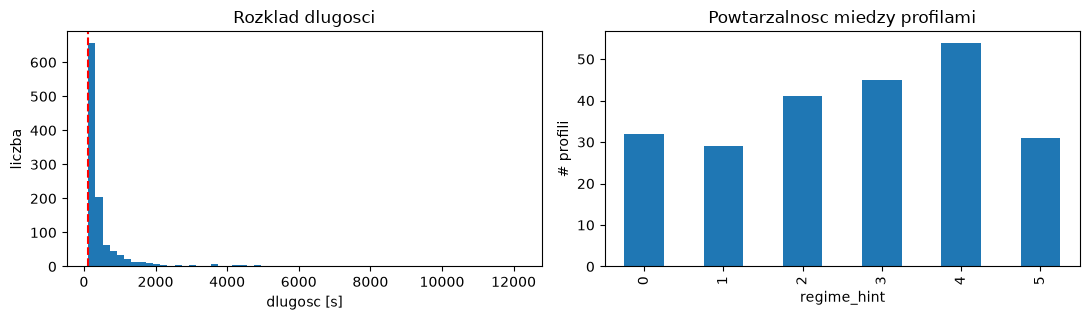

Segmentow train: 734 | val: 190 | test: 194


In [13]:
fig,ax=plt.subplots(1,2,figsize=(11,3.3))
ax[0].hist(segments.duration_s,bins=60); ax[0].axvline(MIN_SEGMENT_S,ls="--",color="r")
ax[0].set(xlabel="dlugosc [s]",ylabel="liczba",title="Rozklad dlugosci")
agg["profiles"].plot(kind="bar",ax=ax[1]); ax[1].set(xlabel="regime_hint",ylabel="# profili",title="Powtarzalnosc miedzy profilami")
fig.tight_layout(); plt.show()
print("Segmentow train:",int((segments.split=="train").sum()),
      "| val:",int((segments.split=="val").sum()),
      "| test:",int((segments.split=="test").sum()))

## 11. Eksport dla NB#3
`segments_features.csv` (A, kolumny `split`/`in_train`) + `segments_series_shape.npy` i `segments_series_level.npy` (B, dwa warianty) + `segments_series_index.csv` (ta sama flaga `split` per wiersz `.npy`) + `segmentation_config.json` (źródło podziału, `train_ids`/`val_ids`/`test_ids`) + `segmentation_sensitivity.csv`.

In [14]:
# segments_features.csv zawiera jawne kolumny 'split' oraz 'in_train' (per segment).
segments.to_csv(OUT/"segments_features.csv",index=False)
np.save(OUT/"segments_series_shape.npy",series_shape)
np.save(OUT/"segments_series_level.npy",series_level)
# Indeks wierszy dla tablic .npy z JAWNA flaga podzialu (wiersz i-ty <-> series_*[i]).
pd.DataFrame([{ID:p,"segment_id":sid,"start_sample":s,"end_sample":e,"row":i,
               "split":split_map[int(p)],"in_train":p in train_ids}
             for i,(p,sid,s,e) in enumerate(seg_index)]).to_csv(OUT/"segments_series_index.csv",index=False)
sensitivity.to_csv(OUT/"segmentation_sensitivity.csv",index=False)
cmp.to_csv(OUT/"segmentation_method_comparison.csv",index=False)
json.dump({"features_repr":"segments_features.csv",
           "series_shape":"segments_series_shape.npy","series_level":"segments_series_level.npy",
           "series_dims":list(series_shape.shape),"drivers":DRIVERS,"regime_features":REGIME_FEATURES,
           "BLOCK":BLOCK,"CP_QUANTILE":CP_QUANTILE,"MIN_SEGMENT_S":MIN_SEGMENT_S,"RESAMPLE_LEN":RESAMPLE_LEN,
           "STEADY_MAX_TRANSIENT_FRAC":STEADY_MAX_TRANSIENT_FRAC,"feature_cols":FEATURE_COLS,
           "split_source":str(SPLIT_PATH),"split_scheme":"GroupShuffleSplit 70/15/15 (EDA rozdz. 22.4)",
           "split_flags":{"segments_features.csv":["split","in_train"],
                          "segments_series_index.csv":["split","in_train"]},
           "train_ids":sorted(map(int,train_ids)),"val_ids":sorted(map(int,val_ids)),
           "test_ids":sorted(map(int,test_ids)),
           "pelt_backend":("ruptures" if HAS_RPT else "numpy_fallback"),
           "segmentation":"method-agnostic greedy change-point (validated by BinSeg/PELT)"},
          open(OUT/"segmentation_config.json","w"),indent=2)
print("Zapisano:",sorted(p.name for p in OUT.glob('segment*')))

Zapisano: ['segmentation_config.json', 'segmentation_method_comparison.csv', 'segmentation_sensitivity.csv', 'segments_features.csv', 'segments_series_index.csv', 'segments_series_level.npy', 'segments_series_shape.npy']


## 12. Wnioski i komentarz krytyczny

**Mocne strony**
- Segmentacja **metod-agnostyczna** i **odporna**: greedy vs BinSeg vs PELT (`ruptures`, a gdy pakiet nie jest zainstalowany — szybki proxy BinSeg z inną karą) dają trójstronną walidację granic. Brak `ruptures` jest logowany i **nie ucina** wykresu porównawczego.
- **Brak leakage i pełna powtarzalność**: podział `train/val/test` wczytany z EDA (`profile_split.csv`, `GroupShuffleSplit` 70/15/15) — bez losowania w tym notebooku; `pm`/temperatury wykluczone; skaler, próg transientów i `tau` (Greedy CP) kalibrowane **wyłącznie na `train`**; flagi `split`/`in_train` przekazane dalej.
- **Bez współliniowości elektrycznej**: wektor `REGIME_FEATURES` zawiera tylko składowe d-q (bez modułów `i_s`/`u_s`), co chroni metryki dystansowe przed sztucznym podwajaniem wagi sygnałów elektrycznych.
- **Podwójna reprezentacja B (shape + level)** i flaga `is_steady` dają NB#3 realne warianty do uczciwego porównania rodzin metod.

**Ograniczenia (świadome)**
- Progi `tau`/`MIN_SEGMENT_S`/`pen` dobrane heurystycznie — sekcja 5.2 pokazuje zależność, ale nie ma „obiektywnego" optimum bez kryterium zadaniowego (regresja `pm` w NB#5).
- Reprezentacja `shape` usuwa poziom i długość; `feature` spłaszcza wielomodalność — stąd umiarkowany silhouette. To nie błąd, lecz powód, dla którego porównanie metod ma sens.
- `regime_hint` z KMeans jest wyłącznie opisowy; nie należy go używać jako etykiet odniesienia.

**Dla NB#3:** wczytać obie reprezentacje B + cechy A; uruchomić metody na `train`, przypisać `test`; porównać wg metryk wewnętrznych, stabilności (ARI), obsługi szumu oraz kryterium zadaniowego (poprawa regresji `pm` po augmentacji wewnątrz klastrów). Rozważyć warianty: all vs steady-only, shape vs level.

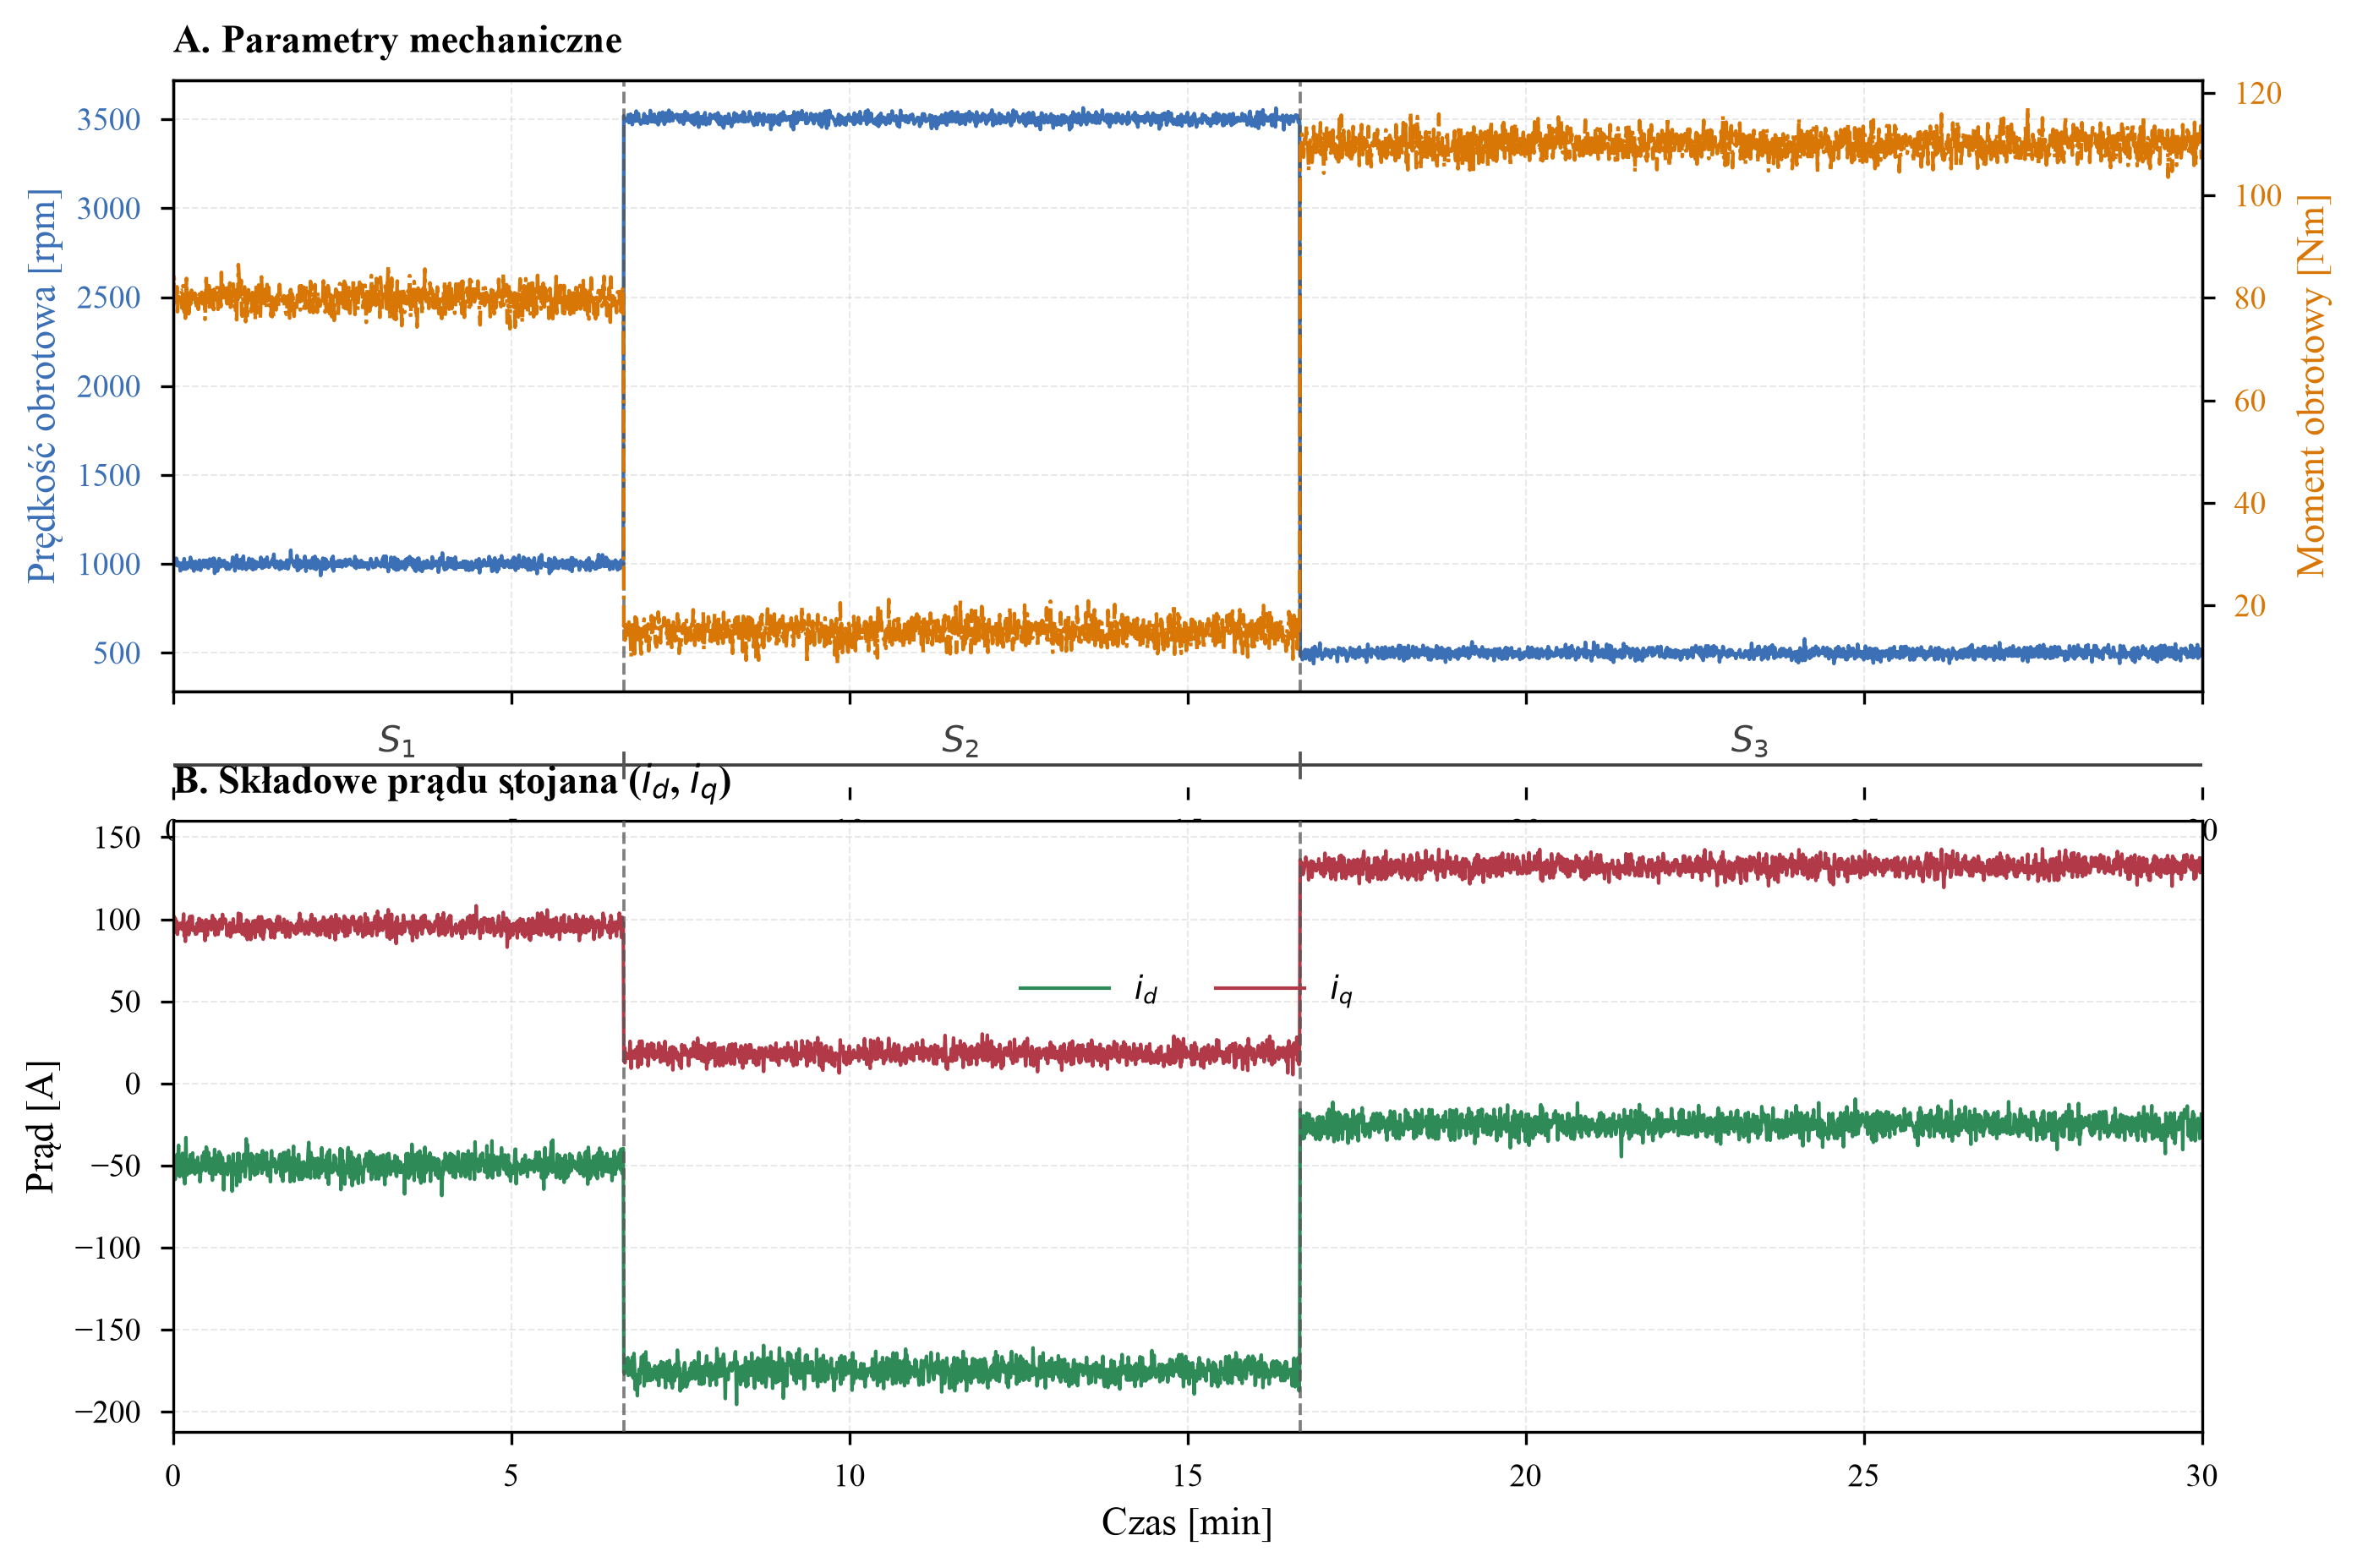

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Konfiguracja stylu akademickiego
# ============================================================

plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
})


# ============================================================
# 2. Parametry
# ============================================================

FS = 2          # Hz
PROFILE_ID = 4
TAU = 0.600


# ============================================================
# 3. Przykładowe dane
# ============================================================

np.random.seed(42)

time_s = np.arange(0, 1800, 1 / FS)
time_min = time_s / 60
n_samples = len(time_s)


# ------------------------------------------------------------
# Parametry mechaniczne
# ------------------------------------------------------------

speed = np.piecewise(
    time_s,
    [
        time_s < 400,
        (time_s >= 400) & (time_s < 1000),
        time_s >= 1000,
    ],
    [1000, 3500, 500],
) + np.random.normal(
    0, 20, n_samples
)


torque = np.piecewise(
    time_s,
    [
        time_s < 400,
        (time_s >= 400) & (time_s < 1000),
        time_s >= 1000,
    ],
    [80, 15, 110],
) + np.random.normal(
    0, 2, n_samples
)


# ------------------------------------------------------------
# Składowe prądu stojana
# ------------------------------------------------------------

i_d = (
    -0.05 * speed
    + np.random.normal(0, 5, n_samples)
)

i_q = (
    1.2 * torque
    + np.random.normal(0, 3, n_samples)
)


# ============================================================
# 4. Granice segmentacji
# ============================================================

boundaries_s = [
    0,
    400,
    1000,
    1800,
]

boundaries_min = np.asarray(boundaries_s) / 60


# ============================================================
# 5. Kolorystyka
# ============================================================

color_speed = "#3B6FB6"
color_torque = "#D97706"

color_id = "#2E8B57"
color_iq = "#B23A48"

color_boundary = "#555555"
color_segment = "#404040"


# ============================================================
# 6. Układ rysunku
# ============================================================
#
# 3 wiersze:
#
#   1. Panel A
#   2. Pasek segmentacji
#   3. Panel B
#
# Pasek segmentacji jest bardzo niski.
# ============================================================

fig = plt.figure(
    figsize=(10, 6.2),
    dpi=300,
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=1,
    height_ratios=[
        1.0,    # Panel A
        0.10,   # Pasek segmentów
        1.0,    # Panel B
    ],
    hspace=0.08,
)

ax1 = fig.add_subplot(gs[0])
ax_seg = fig.add_subplot(gs[1], sharex=ax1)
ax2 = fig.add_subplot(gs[2], sharex=ax1)


# ============================================================
# 7. PANEL A – parametry mechaniczne
# ============================================================

ax1.plot(
    time_min,
    speed,
    color=color_speed,
    linewidth=1.05,
    zorder=2,
)

ax1.set_ylabel(
    "Prędkość obrotowa [rpm]",
    color=color_speed,
)

ax1.tick_params(
    axis="y",
    labelcolor=color_speed,
)

ax1.set_title(
    "A. Parametry mechaniczne",
    loc="left",
    weight="bold",
    pad=8,
)


# ------------------------------------------------------------
# Druga oś Y – moment obrotowy
# ------------------------------------------------------------

ax1_twin = ax1.twinx()

ax1_twin.plot(
    time_min,
    torque,
    color=color_torque,
    linewidth=1.05,
    linestyle="-.",
    zorder=2,
)

ax1_twin.set_ylabel(
    "Moment obrotowy [Nm]",
    color=color_torque,
)

ax1_twin.tick_params(
    axis="y",
    labelcolor=color_torque,
)


# ============================================================
# 8. PANEL B – składowe prądu
# ============================================================

ax2.plot(
    time_min,
    i_d,
    color=color_id,
    linewidth=1.0,
    label=r"$i_d$",
    zorder=2,
)

ax2.plot(
    time_min,
    i_q,
    color=color_iq,
    linewidth=1.0,
    label=r"$i_q$",
    zorder=2,
)

ax2.set_ylabel(
    "Prąd [A]"
)

ax2.set_xlabel(
    "Czas [min]"
)

ax2.set_title(
    r"B. Składowe prądu stojana ($i_d$, $i_q$)",
    loc="left",
    weight="bold",
    pad=8,
)


# ============================================================
# 9. Legenda panelu B
# ============================================================

ax2.legend(
    loc="center",
    bbox_to_anchor=(0.50, 0.72),
    ncol=2,
    frameon=False,
    handlelength=2.8,
    columnspacing=1.8,
)


# ============================================================
# 10. Siatka
# ============================================================

for ax in (ax1, ax2):

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.28,
        zorder=0,
    )


# ============================================================
# 11. Punkty zmiany na właściwych wykresach
# ============================================================

for boundary in boundaries_min[1:-1]:

    ax1.axvline(
        boundary,
        color=color_boundary,
        linestyle="--",
        linewidth=0.9,
        alpha=0.75,
        zorder=5,
    )

    ax2.axvline(
        boundary,
        color=color_boundary,
        linestyle="--",
        linewidth=0.9,
        alpha=0.75,
        zorder=5,
    )


# ============================================================
# 12. OSOBNY PASEK SEGMENTACJI
# ============================================================

# Usuwamy wszystkie elementy typowej osi
ax_seg.set_ylim(0, 1)

ax_seg.set_yticks([])
ax_seg.set_xticks([])

for spine in ax_seg.spines.values():
    spine.set_visible(False)


# ------------------------------------------------------------
# Środki segmentów
# ------------------------------------------------------------

segment_centers = (
    boundaries_min[:-1]
    + boundaries_min[1:]
) / 2


# ------------------------------------------------------------
# Linie reprezentujące zakres segmentów
# ------------------------------------------------------------

for i, (left, right, center) in enumerate(
    zip(
        boundaries_min[:-1],
        boundaries_min[1:],
        segment_centers,
    ),
    start=1,
):

    # pozioma linia segmentu
    ax_seg.plot(
        [left, right],
        [0.35, 0.35],
        color=color_segment,
        linewidth=0.9,
        solid_capstyle="butt",
    )

    # etykieta segmentu
    ax_seg.text(
        center,
        0.72,
        rf"$S_{{{i}}}$",
        ha="center",
        va="center",
        fontsize=10,
        color=color_segment,
    )


# ------------------------------------------------------------
# Znaczniki granic na pasku
# ------------------------------------------------------------

for boundary in boundaries_min[1:-1]:

    ax_seg.plot(
        [boundary, boundary],
        [0.15, 0.55],
        color=color_boundary,
        linewidth=0.9,
    )


# ============================================================
# 13. Zakres osi czasu
# ============================================================

ax2.set_xlim(
    boundaries_min[0],
    boundaries_min[-1],
)

ax2.set_xticks(
    np.arange(
        0,
        boundaries_min[-1] + 0.1,
        5,
    )
)


# Ukrycie etykiet X panelu A
ax1.tick_params(
    axis="x",
    labelbottom=False,
)


# ============================================================
# 14. Marginesy
# ============================================================

ax1.margins(x=0)
ax2.margins(x=0)
ax_seg.margins(x=0)


# ============================================================
# 15. Finalizacja układu
# ============================================================

fig.subplots_adjust(
    top=0.96,
    bottom=0.10,
    left=0.10,
    right=0.90,
)


# ============================================================
# 16. Zapis PNG
# ============================================================

plt.savefig(
    "rysunek_5_1_greedy_cp_segmentation.png",
    dpi=300,
    bbox_inches="tight",
)


# ============================================================
# 17. Zapis PDF – format wektorowy
# ============================================================

plt.savefig(
    "rysunek_5_1_greedy_cp_segmentation.pdf",
    bbox_inches="tight",
)


# ============================================================
# 18. Wyświetlenie
# ============================================================

plt.show()